In [ ]:
import pandas as pd
import numpy as np
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score,mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from scipy.stats import skew
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
df_train=pd.read_excel('timeseries_table_history (28).xlsx',parse_dates=['Timestamp'])
df_val=pd.read_excel('timeseries_table_history (29).xlsx',parse_dates=['Timestamp'])
df_test=pd.read_excel('timeseries_table_history (30).xlsx',parse_dates=['Timestamp'])
df_forecast=pd.read_excel('timeseries_table_history (31).xlsx',parse_dates=['Timestamp'])

In [ ]:
df_train=df_train[['Timestamp','Boiler Pressure P1','FeedWater TDS','Drum Water  TDS']]
df_val=df_val[['Timestamp','Boiler Pressure P1','FeedWater TDS','Drum Water  TDS']]
df_test=df_test[['Timestamp','Boiler Pressure P1','FeedWater TDS','Drum Water  TDS']]
df_forecast=df_forecast[['Timestamp','Boiler Pressure P1','FeedWater TDS','Drum Water  TDS']]

In [ ]:
df_train.dropna(inplace=True)
df_val.dropna(inplace=True)
df_test.dropna(inplace=True)
df_forecast.dropna(inplace=True)

In [ ]:
df_combined=pd.concat([df_train,df_val,df_test,df_forecast])
df_combined

In [ ]:
# Select only numeric columns for correlation calculation
numeric_df = df_combined.select_dtypes(include=np.number)

# Calculate the correlation of numeric columns with 'Boiler Pressure P1'
correlations = numeric_df.corr()['Drum Water  TDS']
display(correlations)

,Drum Water TDS
Boiler Pressure P1,0.035135
FeedWater TDS,-0.132899
Drum Water TDS,1.000000


In [ ]:
# Select only numeric columns for correlation calculation
numeric_df = df_train.select_dtypes(include=np.number)

# Calculate the correlation of numeric columns with 'Boiler Pressure P1'
correlations = numeric_df.corr()['Drum Water  TDS']
display(correlations)

,Drum Water TDS
Boiler Pressure P1,0.159152
FeedWater TDS,-0.444937
Drum Water TDS,1.000000


In [ ]:
numeric_df1=df_val.select_dtypes(include=np.number)
correlations1=numeric_df1.corr()['Drum Water  TDS']
display(correlations1)

,Drum Water TDS
Boiler Pressure P1,-0.185132
FeedWater TDS,0.103996
Drum Water TDS,1.000000


In [ ]:
numeric_df2=df_test.select_dtypes(include=np.number)
correlations2=numeric_df2.corr()['Drum Water  TDS']
display(correlations2)

,Drum Water TDS
Boiler Pressure P1,0.166323
FeedWater TDS,-0.680076
Drum Water TDS,1.000000


In [ ]:
numeric_df3=df_forecast.select_dtypes(include=np.number)
correlations3=numeric_df3.corr()['Drum Water  TDS']
display(correlations3)

,Drum Water TDS
Boiler Pressure P1,0.526548
FeedWater TDS,-0.449875
Drum Water TDS,1.000000


In [ ]:
window_size=7
roll_features=['Boiler Pressure P1','FeedWater TDS']
def rolling_average(df, window_size, roll_features):
    for feature in roll_features:
        df[f'{feature} Rolling'] = df[feature].rolling(window=window_size).mean()
        df
    return df

In [ ]:
df_train = rolling_average(df_train, window_size, roll_features)
df_val = rolling_average(df_val, window_size, roll_features)
df_test = rolling_average(df_test, window_size, roll_features)
df_forecast = rolling_average(df_forecast, window_size, roll_features)

df_train.fillna(method='ffill', inplace=True)
df_val.fillna(method='ffill', inplace=True)
df_test.fillna(method='ffill', inplace=True)
df_forecast.fillna(method='ffill', inplace=True)

df_train.fillna(method='bfill', inplace=True)
df_val.fillna(method='bfill', inplace=True)
df_test.fillna(method='bfill', inplace=True)
df_forecast.fillna(method='bfill', inplace=True)


display(df_train.head())
display(df_val.head())
display(df_test.head())
display(df_forecast.head())

In [ ]:
# 2. IQR Outlier Capping Function
def cap_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df.loc[df[col] > upper, col] = upper
        df.loc[df[col] < lower, col] = lower
    return df

features = ['Boiler Pressure P1', 'FeedWater TDS','Boiler Pressure P1 Rolling','FeedWater TDS Rolling']
target = 'Drum Water  TDS'
all_columns = features + [target]

# 3. Cap Outliers in All DFs
df_train = cap_outliers_iqr(df_train, all_columns)
df_val = cap_outliers_iqr(df_val, all_columns)
df_test = cap_outliers_iqr(df_test, all_columns)
df_forecast = cap_outliers_iqr(df_forecast, all_columns)

In [ ]:
df_test

In [ ]:
df_val

In [ ]:
df_forecast

In [ ]:
df_train

In [ ]:
f1=df_train[['Boiler Pressure P1','FeedWater TDS']]
f2=df_val[['Boiler Pressure P1','FeedWater TDS']]
f3=df_test[['Boiler Pressure P1','FeedWater TDS']]
f4=df_forecast[['Boiler Pressure P1','FeedWater TDS']]

In [ ]:
for i in f1:
  print(i,skew(f1[i]))

Boiler Pressure P1 1.200300026473009
FeedWater TDS -0.11441074659184004


In [ ]:
for i in f2:
  print(i,skew(f2[i]))

Boiler Pressure P1 1.158916456386991
FeedWater TDS 0.23685184755867517


In [ ]:
for i in f3:
  print(i,skew(f3[i]))

Boiler Pressure P1 1.0095360292221758
FeedWater TDS 0.5276530041901054


In [ ]:
for i in f4:
  print(i,skew(f4[i]))

Boiler Pressure P1 0.8339304527984392
FeedWater TDS 0.1315307313831015


In [ ]:
# 3. Box-Cox Transformation (before scaling)
min_target = min(
    df_train[target].min(),
    df_val[target].min(),
    df_test[target].min(),
    df_forecast[target].min()
)

shift = 1 - min_target if min_target <= 0 else 0

# Shift target values
df_train[target] += shift
df_val[target] += shift
df_test[target] += shift
df_forecast[target] += shift

# Fit Box-Cox on training set target
df_train[target], boxcox_lambda = boxcox(df_train[target])

# Apply same Box-Cox transformation on val/test/forecast
df_val[target] = boxcox(df_val[target], lmbda=boxcox_lambda)
df_test[target] = boxcox(df_test[target], lmbda=boxcox_lambda)
df_forecast[target] = boxcox(df_forecast[target], lmbda=boxcox_lambda)

In [ ]:
#4. Scaling
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(df_train[all_columns])
val_scaled = scaler.transform(df_val[all_columns])
test_scaled = scaler.transform(df_test[all_columns])
forecast_scaled = scaler.transform(df_forecast[all_columns])

# Save target scaler
scaler_y = MinMaxScaler()
scaler_y.fit(df_train[[target]])

# 5. Sequence Generation
sequence_length = 15

def create_sequences(data, seq_len):
    x, y = [], []
    for i in range(len(data) - seq_len):
        x.append(data[i:i+seq_len, :-1]) # features only
        y.append(data[i+seq_len, -1]) # target at next step
    return np.array(x), np.array(y)

x_train, y_train = create_sequences(train_scaled, sequence_length)
x_val, y_val = create_sequences(val_scaled, sequence_length)
x_test, y_test = create_sequences(test_scaled, sequence_length)
x_forecast, y_forecast = create_sequences(forecast_scaled, sequence_length)

In [ ]:
# 6. LSTM Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(sequence_length, len(features))),
    tf.keras.layers.LSTM(64, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.0005)), # Increased units and added L2 regularization
    tf.keras.layers.Dropout(0.2), # Added Dropout layer
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mae', metrics=['mse'])


# 7. Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_lstm_model.keras', save_best_only=True)
]

In [ ]:
history=model.fit(
    x_train, y_train,
    epochs=50, # Increased epochs
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

Epoch 1/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0754 - mse: 0.0199 - val_loss: 0.3241 - val_mse: 0.1048
Epoch 2/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0715 - mse: 0.0189 - val_loss: 0.3266 - val_mse: 0.1065
Epoch 3/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0683 - mse: 0.0183 - val_loss: 0.3005 - val_mse: 0.0909
Epoch 4/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0679 - mse: 0.0188 - val_loss: 0.3098 - val_mse: 0.0968
Epoch 5/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0651 - mse: 0.0184 - val_loss: 0.3323 - val_mse: 0.1117
Epoch 6/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0644 - mse: 0.0190 - val_loss: 0.2916 - val_mse: 0.0894
Epoch 7/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0612 - mse: 0.0183 - val_loss: 0.3308 - val_mse: 0.1123
Epoch 8/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0619 - mse: 0.0190 - val_loss: 0.3433 - val_mse: 0.1199
Epoch 9/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - lo

In [ ]:
# 9. Predict & Inverse Scaling + Inverse Box-Cox

# 1. Predict from LSTM
y_pred_test = model.predict(x_test).flatten()
y_pred_forecast = model.predict(x_forecast).flatten()

# 2. Inverse MinMax Scaling
y_pred_test_scaled_inv = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_scaled_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

y_pred_forecast_scaled_inv = scaler_y.inverse_transform(y_pred_forecast.reshape(-1, 1)).flatten()
y_forecast_scaled_inv = scaler_y.inverse_transform(y_forecast.reshape(-1, 1)).flatten()

# 3. Inverse Box-Cox
y_pred_test_inv = inv_boxcox(y_pred_test_scaled_inv, boxcox_lambda) - shift
y_test_inv = inv_boxcox(y_test_scaled_inv, boxcox_lambda) - shift

y_pred_forecast_inv = inv_boxcox(y_pred_forecast_scaled_inv, boxcox_lambda) - shift
y_forecast_inv = inv_boxcox(y_forecast_scaled_inv, boxcox_lambda) - shift

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# 12. Metrics
print("MAE (Test):", mean_absolute_error(y_test_inv, y_pred_test_inv))

MAE (Test): 1337.3358889416202


In [ ]:

print("MAE (Forecast):", mean_absolute_error(y_forecast_inv, y_pred_forecast_inv))

MAE (Forecast): 1486.3619594249742


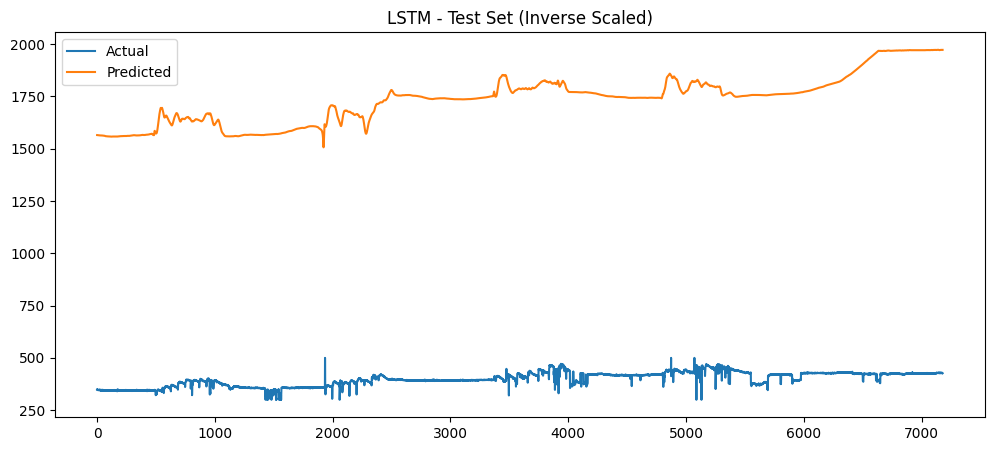

In [ ]:
# 10. Plot - Test Set
# -------------------------
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_test_inv, label='Predicted')
plt.title("LSTM - Test Set (Inverse Scaled)")
plt.legend()
plt.show()

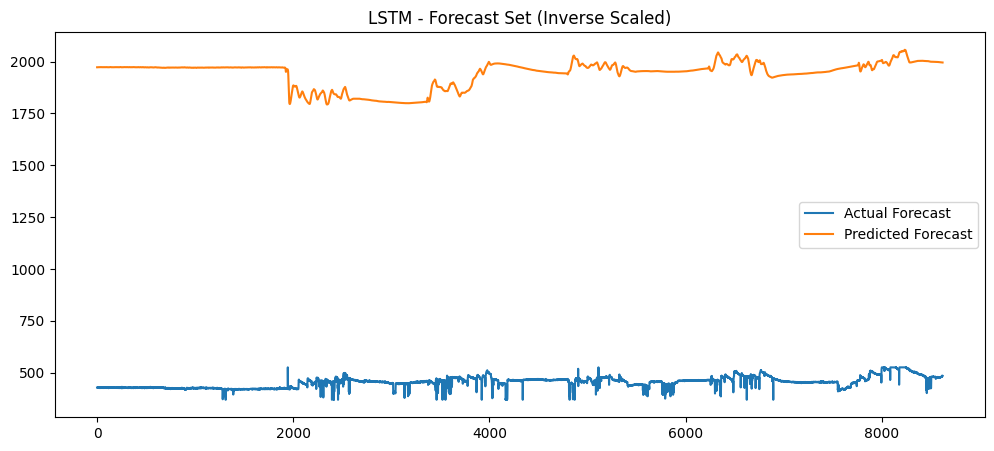

In [ ]:
# 11. Plot - Forecast Set
# -------------------------
plt.figure(figsize=(12,5))
plt.plot(y_forecast_inv, label='Actual Forecast')
plt.plot(y_pred_forecast_inv, label='Predicted Forecast')
plt.title("LSTM - Forecast Set (Inverse Scaled)")
plt.legend()
plt.show()

In [ ]:
# === BIAS CORRECTION ON TEST SET ===

predictions = np.array(y_pred_test_inv)
targets = np.array(y_test_inv)

bias = (predictions - targets).mean()
print(f"\nTest Set Bias: {bias:.4f}")

corrected_predictions = predictions - bias

# Evaluate
mae = mean_absolute_error(targets, corrected_predictions)
mape = mean_absolute_percentage_error(targets, corrected_predictions)
mse = mean_squared_error(targets, corrected_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(targets, corrected_predictions)

print(f"\nTest Set After Bias Correction:")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape*100:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# === BIAS CORRECTION ON FORECAST SET ===

forecast_predictions = np.array(y_pred_forecast_inv)
forecast_targets = np.array(y_forecast_inv)

forecast_bias = (forecast_predictions - forecast_targets).mean()
print(f"\nForecast Set Bias: {forecast_bias:.4f}")

corrected_forecast_predictions = forecast_predictions - forecast_bias

# Evaluate
mae_f = mean_absolute_error(forecast_targets, corrected_forecast_predictions)
mape_f = mean_absolute_percentage_error(forecast_targets, corrected_forecast_predictions)
mse_f = mean_squared_error(forecast_targets, corrected_forecast_predictions)
rmse_f = np.sqrt(mse_f)

print(f"\nForecast Set After Bias Correction:")
print(f"MAE: {mae_f:.4f}")
print(f"MAPE: {mape_f*100:.4f}")
print(f"MSE: {mse_f:.4f}")
print(f"RMSE: {rmse_f:.4f}")


Test Set Bias: 1337.3359

Test Set After Bias Correction:
MAE: 66.7738
MAPE: 17.2027
MSE: 8194.6997
RMSE: 90.5246

Forecast Set Bias: 1486.3620

Forecast Set After Bias Correction:
MAE: 50.9798
MAPE: 11.3828
MSE: 4238.3551
RMSE: 65.1027


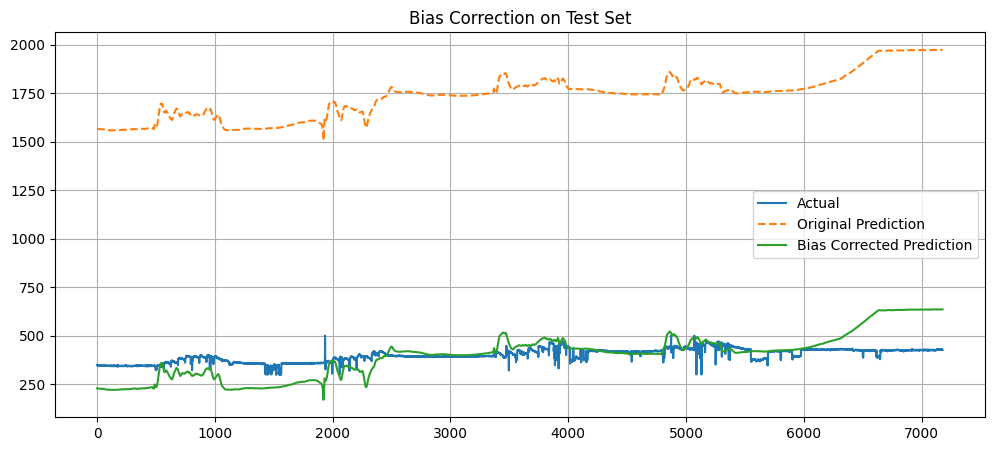

In [ ]:
# Plot corrected test predictions
plt.figure(figsize=(12,5))
plt.plot(targets, label='Actual')
plt.plot(predictions, label='Original Prediction', linestyle='--')
plt.plot(corrected_predictions, label='Bias Corrected Prediction')
plt.legend()
plt.title("Bias Correction on Test Set")
plt.grid(True)
plt.show()


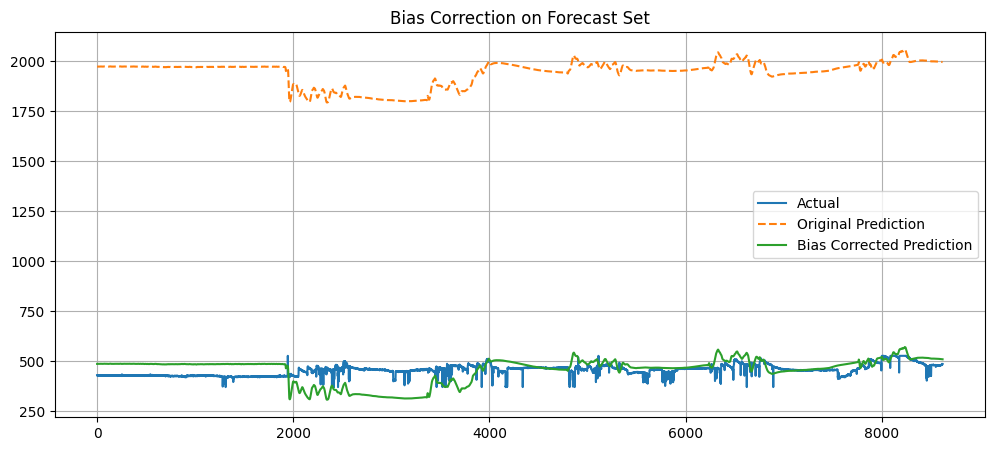

In [ ]:

# Plot corrected forecast
plt.figure(figsize=(12,5))
plt.plot(forecast_targets, label='Actual')
plt.plot(forecast_predictions, label='Original Prediction', linestyle='--')
plt.plot(corrected_forecast_predictions, label='Bias Corrected Prediction')
plt.legend()
plt.title("Bias Correction on Forecast Set")
plt.grid(True)
plt.show()